In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Academic visualization configuration for inline display in Jupyter
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 120,    # Notebook inline display resolution
    'savefig.dpi': 300,   # Export image resolution
    'savefig.bbox': 'tight',
    'axes.axisbelow': True 
})

# Text box styling and Color Palette
text_bbox = dict(facecolor='white', edgecolor='none', alpha=0.9, pad=1.5)
COLORS = {
    'old': '#8c8c8c',      # Neutral grey for Baseline / Previous setup
    'new': '#2ca02c',      # Green for Proposed / New architecture
    'danger': '#d62728',   # Red for Non-stationary / Ablated models
    'safe': '#1f77b4',     # Blue for Stationary / Full models
}

# 2. Path configuration (Adjust project_root if running from a different directory)
project_root = Path("C:/Users/huy/Documents/GreenWich/COMP1682.1_FinalProject/Project")
results_dir = project_root / "results"
viz_dir = results_dir / "figures"
viz_dir.mkdir(parents=True, exist_ok=True)

# 3. Utility helper functions
def load_json(filename):
    filepath = results_dir / filename
    if not filepath.exists():
        print(f"Warning: Missing {filename}. Skipping...")
        return None
    with open(filepath, 'r') as f:
        return json.load(f)

def despine(ax):
    """Remove top and right spines from the plot."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

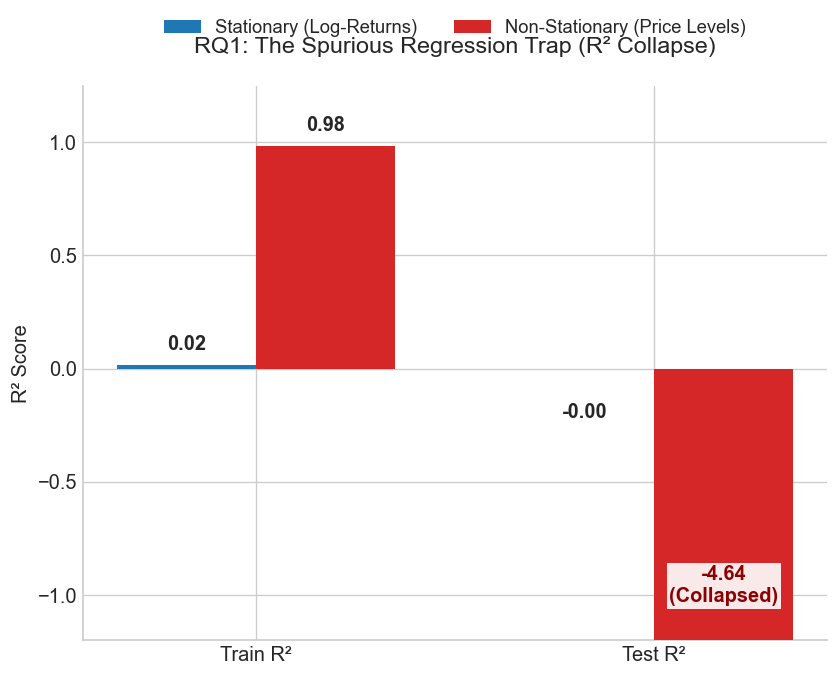

In [2]:
data = load_json("rq1_stationarity_results.json")
if data:
    categories = ['Train R²', 'Test R²']
    returns_r2 = [data["Stationary_Returns"]["Train"]["R2"], data["Stationary_Returns"]["Test"]["R2"]]
    prices_r2 = [data["NonStationary_Prices"]["Train"]["R2"], data["NonStationary_Prices"]["Test"]["R2"]]
    
    x = np.arange(len(categories))
    width = 0.35
    
    fig, ax1 = plt.subplots(figsize=(8, 6))
    
    rects1 = ax1.bar(x - width/2, returns_r2, width, label='Stationary (Log-Returns)', color=COLORS['safe'], zorder=3)
    rects2 = ax1.bar(x + width/2, prices_r2, width, label='Non-Stationary (Price Levels)', color=COLORS['danger'], zorder=3)
    
    ax1.set_ylabel('R² Score')
    ax1.set_title('RQ1: The Spurious Regression Trap (R² Collapse)', pad=20)
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories)
    ax1.set_ylim(-1.2, 1.25) 
    
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)
    despine(ax1)
    
    for rects in [rects1, rects2]:
        for rect in rects:
            height = rect.get_height()
            if height < -1.0:
                ax1.text(rect.get_x() + rect.get_width()/2, -1.05, 
                         f'{height:.2f}\n(Collapsed)', ha='center', va='bottom', 
                         fontweight='bold', color='darkred', bbox=text_bbox)
            else:
                offset = 0.05 if height >= 0 else -0.15
                va = 'bottom' if height >= 0 else 'top'
                ax1.text(rect.get_x() + rect.get_width()/2, height + offset, 
                         f'{height:.2f}', ha='center', va=va, fontweight='bold', bbox=text_bbox)
            
    plt.savefig(viz_dir / "rq1_spurious_regression_clean.png")
    plt.show()  # Display inline in Jupyter

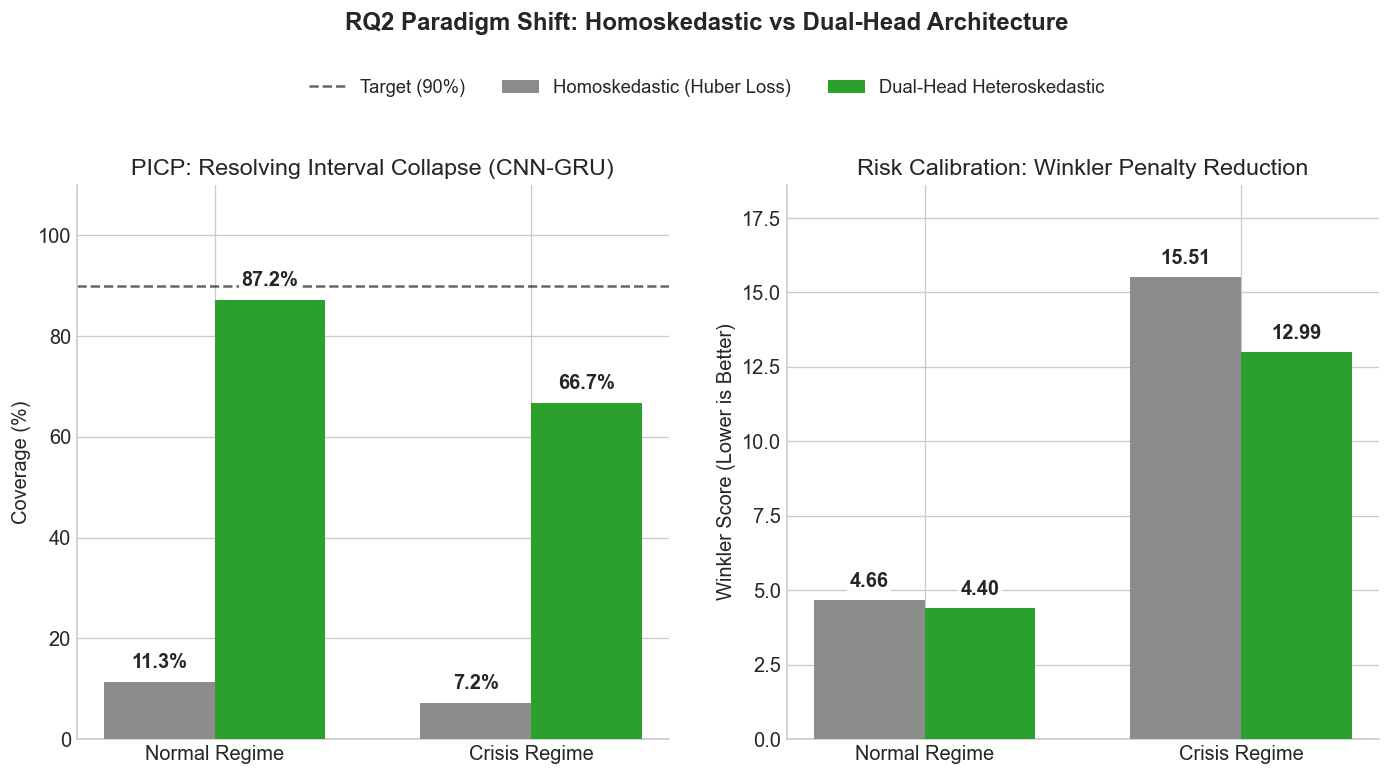

In [3]:
old_data = load_json("rq2_uncertainty_results_old.json")
new_data = load_json("rq2_uncertainty_results_2.json")

if old_data and new_data:
    old_cnn = old_data["CNN_GRU"]
    new_cnn = new_data["CNN_GRU"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    x = np.arange(2)
    width = 0.35

    # --- PICP Subplot ---
    old_picp = [old_cnn["Normal_Uncertainty"]["PICP"] * 100, old_cnn["Crisis_Uncertainty"]["PICP"] * 100]
    new_picp = [new_cnn["Normal_Uncertainty"]["PICP"] * 100, new_cnn["Crisis_Uncertainty"]["PICP"] * 100]

    rects1 = ax1.bar(x - width/2, old_picp, width, label='Homoskedastic (Huber Loss)', color=COLORS['old'], zorder=3)
    rects2 = ax1.bar(x + width/2, new_picp, width, label='Dual-Head Heteroskedastic', color=COLORS['new'], zorder=3)

    ax1.set_ylabel('Coverage (%)')
    ax1.set_title('PICP: Resolving Interval Collapse (CNN-GRU)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(['Normal Regime', 'Crisis Regime'])
    ax1.set_ylim(0, 110)
    ax1.axhline(y=90, color='black', linestyle='--', alpha=0.6, label='Target (90%)')
    despine(ax1)

    for rects in [rects1, rects2]:
        for rect in rects:
            h = rect.get_height()
            ax1.text(rect.get_x() + rect.get_width()/2, h + 2, f'{h:.1f}%', ha='center', va='bottom', fontweight='bold', bbox=text_bbox)

    # --- Winkler Subplot ---
    old_winkler = [old_cnn["Normal_Uncertainty"]["Winkler"], old_cnn["Crisis_Uncertainty"]["Winkler"]]
    new_winkler = [new_cnn["Normal_Uncertainty"]["Winkler"], new_cnn["Crisis_Uncertainty"]["Winkler"]]

    rects3 = ax2.bar(x - width/2, old_winkler, width, color=COLORS['old'], zorder=3)
    rects4 = ax2.bar(x + width/2, new_winkler, width, color=COLORS['new'], zorder=3)

    ax2.set_ylabel('Winkler Score (Lower is Better)')
    ax2.set_title('Risk Calibration: Winkler Penalty Reduction')
    ax2.set_xticks(x)
    ax2.set_xticklabels(['Normal Regime', 'Crisis Regime'])
    ax2.set_ylim(0, max(old_winkler) * 1.2)
    despine(ax2)

    for rects in [rects3, rects4]:
        for rect in rects:
            h = rect.get_height()
            ax2.text(rect.get_x() + rect.get_width()/2, h + 0.3, f'{h:.2f}', ha='center', va='bottom', fontweight='bold', bbox=text_bbox)

    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=False)
    
    plt.suptitle('RQ2 Paradigm Shift: Homoskedastic vs Dual-Head Architecture', fontweight='bold', y=1.12)
    plt.savefig(viz_dir / "rq2_before_vs_after_clean.png", bbox_inches='tight')
    plt.show()

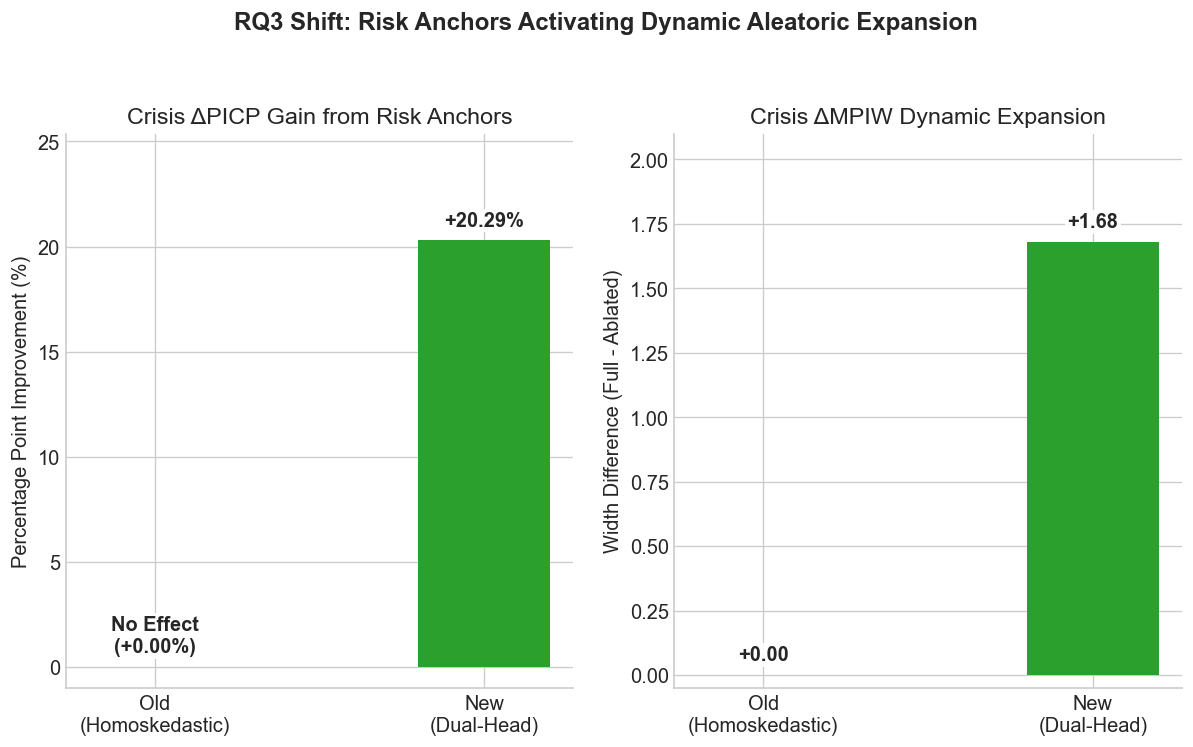

In [4]:
old_data = load_json("rq3_ablation_results_old.json")
new_data = load_json("rq3_ablation_results_2.json")

if old_data and new_data:
    old_delta_picp = (old_data["Model_3_Full"]["Crisis_Uncertainty"]["PICP"] - old_data["Model_3_Ablated"]["Crisis_Uncertainty"]["PICP"]) * 100
    new_delta_picp = (new_data["Model_3_Full"]["Crisis_Uncertainty"]["PICP"] - new_data["Model_3_Ablated"]["Crisis_Uncertainty"]["PICP"]) * 100

    old_delta_mpiw = old_data["Model_3_Full"]["Crisis_Uncertainty"]["MPIW"] - old_data["Model_3_Ablated"]["Crisis_Uncertainty"]["MPIW"]
    new_delta_mpiw = new_data["Model_3_Full"]["Crisis_Uncertainty"]["MPIW"] - new_data["Model_3_Ablated"]["Crisis_Uncertainty"]["MPIW"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    methods = ['Old\n(Homoskedastic)', 'New\n(Dual-Head)']
    bar_colors = [COLORS['old'], COLORS['new']]

    # --- Delta PICP Subplot ---
    bars1 = ax1.bar(methods, [old_delta_picp, new_delta_picp], color=bar_colors, width=0.4, zorder=3)
    ax1.set_title('Crisis ΔPICP Gain from Risk Anchors')
    ax1.set_ylabel('Percentage Point Improvement (%)')
    ax1.set_ylim(-1, max(old_delta_picp, new_delta_picp, 1.0) * 1.25)
    despine(ax1)
    
    for bar in bars1:
        h = bar.get_height()
        label = "No Effect\n(+0.00%)" if abs(h) < 1e-4 else f'+{h:.2f}%'
        y_pos = max(h, 0.5) if abs(h) < 1e-4 else h + 0.5
        ax1.text(bar.get_x() + bar.get_width()/2, y_pos, label, ha='center', va='bottom', fontweight='bold', bbox=text_bbox)

    # --- Delta MPIW Subplot ---
    bars2 = ax2.bar(methods, [old_delta_mpiw, new_delta_mpiw], color=bar_colors, width=0.4, zorder=3)
    ax2.set_title('Crisis ΔMPIW Dynamic Expansion')
    ax2.set_ylabel('Width Difference (Full - Ablated)')
    ax2.set_ylim(-0.05, max(old_delta_mpiw, new_delta_mpiw, 0.1) * 1.25)
    despine(ax2)
    
    for bar in bars2:
        h = bar.get_height()
        label = "No Effect\n(+0.00)" if abs(h) < 1e-4 else f'+{h:.2f}'
        y_pos = max(h, 0.05) if abs(h) < 1e-4 else h + 0.04
        ax2.text(bar.get_x() + bar.get_width()/2, y_pos, label, ha='center', va='bottom', fontweight='bold', bbox=text_bbox)

    plt.suptitle('RQ3 Shift: Risk Anchors Activating Dynamic Aleatoric Expansion', fontweight='bold', y=1.05)
    plt.savefig(viz_dir / "rq3_before_vs_after_clean.png", bbox_inches='tight')
    plt.show()

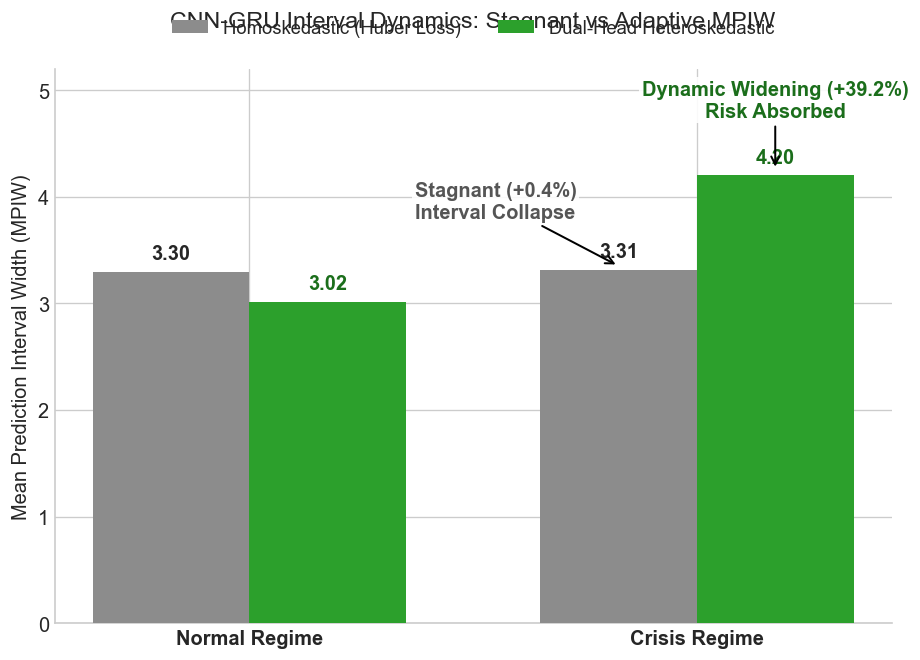

In [5]:
# ==============================================================================
# CELL: Visualizing MPIW Dynamics (Huber Loss vs Dual-Head)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

# Số liệu thực tế từ rq2_uncertainty_results.json và rq2_uncertainty_results_2.json
regimes = ['Normal Regime', 'Crisis Regime']
cnn_huber_mpiw = [3.2978, 3.3124]      # Huber Loss (Homoskedastic)
cnn_dualhead_mpiw = [3.0163, 4.1998]   # Dual-Head (Heteroskedastic)

x = np.arange(len(regimes))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

rects1 = ax.bar(x - width/2, cnn_huber_mpiw, width, 
                label='Homoskedastic (Huber Loss)', color='#8c8c8c', zorder=3)
rects2 = ax.bar(x + width/2, cnn_dualhead_mpiw, width, 
                label='Dual-Head Heteroskedastic', color='#2ca02c', zorder=3)

ax.set_ylabel('Mean Prediction Interval Width (MPIW)')
ax.set_title('CNN-GRU Interval Dynamics: Stagnant vs Adaptive MPIW', pad=25)
ax.set_xticks(x)
ax.set_xticklabels(regimes, fontweight='bold')
ax.set_ylim(0, 5.2)

# Đẩy legend lên trên
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Hiển thị số liệu và độ co giãn
text_box_props = dict(facecolor='white', edgecolor='none', alpha=0.9, pad=1.5)

for rect in rects1:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 0.08, f'{h:.2f}', 
            ha='center', va='bottom', fontweight='bold', bbox=text_box_props)

for rect in rects2:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 0.08, f'{h:.2f}', 
            ha='center', va='bottom', fontweight='bold', color='#1b6e1b', bbox=text_box_props)

# Thêm mũi tên / chú thích nhấn mạnh sự khác biệt
ax.annotate('Stagnant (+0.4%)\nInterval Collapse', 
            xy=(0.825, 3.35), xytext=(0.55, 3.8),
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.2),
            fontweight='bold', color='#555555', ha='center', bbox=text_box_props)

ax.annotate('Dynamic Widening (+39.2%)\nRisk Absorbed', 
            xy=(1.175, 4.25), xytext=(1.175, 4.75),
            arrowprops=dict(facecolor='#2ca02c', arrowstyle='->', lw=1.2),
            fontweight='bold', color='#1b6e1b', ha='center', bbox=text_box_props)

plt.savefig(viz_dir / "mpiw_dynamics_comparison.png", bbox_inches='tight')
plt.show()